In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", None)

In [2]:
train_df = pd.read_csv("../data/raw/sent_train.csv")
valid_df = pd.read_csv("../data/raw/sent_valid.csv")

print("Train Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)

Train Shape: (9543, 2)
Validation Shape: (2388, 2)


In [3]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB


In [5]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [6]:
train_df["label"].value_counts()

label
2    6178
1    1923
0    1442
Name: count, dtype: int64

In [7]:
label_mapping = {
    0: "Bearish",
    1: "Neutral",
    2: "Bullish"
}

print(label_mapping)

{0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}


In [8]:
for label, sentiment in label_mapping.items():
    print(f"\n===== {sentiment} Samples =====")
    samples = train_df[train_df["label"] == label]["text"].sample(3, random_state=42)

    for i, sample in enumerate(samples, 1):
        print(f"\nSample {i}:")
        print(sample)


===== Bearish Samples =====

Sample 1:
Why These Top Oil Stocks All Tumbled More Than 10% in January

Sample 2:
Turkish lira weakens past key 6-per-dollar level

Sample 3:
Norsk Hydro reports lower Q4 earnings on weak aluminum prices

===== Neutral Samples =====

Sample 1:
$CHFS big buyers here. Might bounce before the close.

Sample 2:
$FIZZ - National Beverage +4% as analysts keep scrambling https://t.co/JoctxfxaLB

Sample 3:
Genpact beat estimates in Q4

===== Bullish Samples =====

Sample 1:
(Free to read) Over 60% of Americans say that stock market performance has little or no impact on their personal fi… https://t.co/l3QZQ3KwJy

Sample 2:
Best Buy has dodged death, but for how long? Watch the full video here to see how Best Buy has survived the retail… https://t.co/fvVyAzsL94

Sample 3:
How Good Is CENTROTEC Sustainable AG (ETR:CEV), When It Comes To ROE?


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [10]:
train_df = pd.read_csv("../data/processed/train_processed.csv")

print(train_df.shape)
train_df.head()

(9539, 3)


,text,label,clean_text
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,bynd jpmorgan reels expectations beyond meat
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,ccl rcl nomura points bookings weakness carnival royal caribbean
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,cx cemex cut credit suisse jp morgan weak building outlook
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,ess btig research cuts neutral
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,fnko funko slides piper jaffray pt cut


In [11]:
label_mapping = {
    0: "Bearish",
    1: "Neutral",
    2: "Bullish"
}

train_df["sentiment"] = train_df["label"].map(label_mapping)

train_df.head()

,text,label,clean_text,sentiment
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,bynd jpmorgan reels expectations beyond meat,Bearish
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,ccl rcl nomura points bookings weakness carnival royal caribbean,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,cx cemex cut credit suisse jp morgan weak building outlook,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,ess btig research cuts neutral,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,fnko funko slides piper jaffray pt cut,Bearish


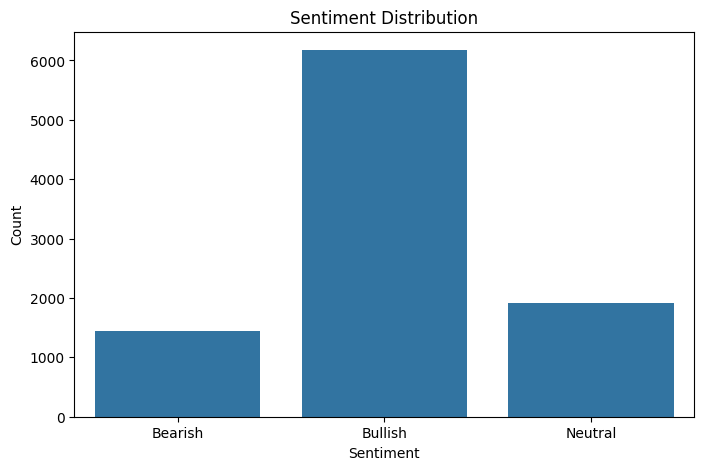

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="sentiment",
    order=["Bearish", "Bullish", "Neutral"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("../outputs/figures/sentiment_distribution.png")

plt.show()

In [13]:
train_df["text_length"] = train_df["clean_text"].apply(lambda x: len(x.split()))

train_df[["clean_text", "text_length"]].head()

,clean_text,text_length
0,bynd jpmorgan reels expectations beyond meat,6
1,ccl rcl nomura points bookings weakness carnival royal caribbean,9
2,cx cemex cut credit suisse jp morgan weak building outlook,10
3,ess btig research cuts neutral,5
4,fnko funko slides piper jaffray pt cut,7


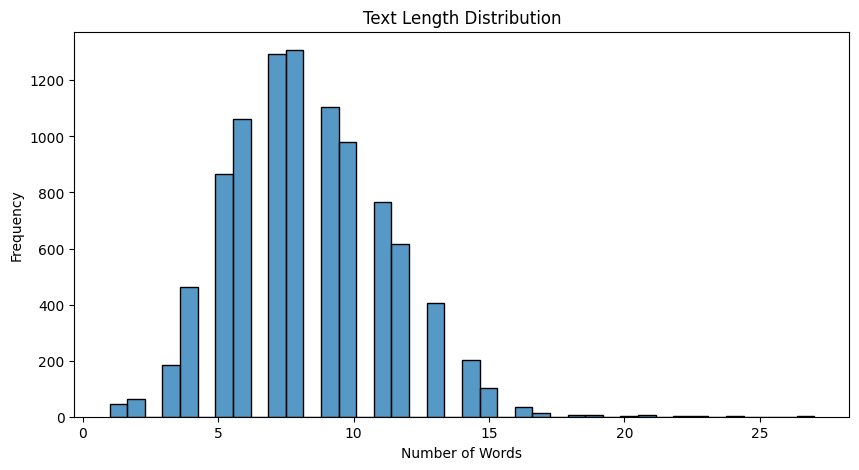

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(train_df["text_length"], bins=40)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/text_length_distribution.png")

plt.show()

In [15]:
train_df.groupby("sentiment")["text_length"].mean()

sentiment
Bearish    8.248960
Bullish    8.395530
Neutral    8.117525
Name: text_length, dtype: float64

In [16]:
train_df["text_length"].describe()

count    9539.000000
mean        8.317329
std         2.901985
min         1.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        27.000000
Name: text_length, dtype: float64